<a href="https://colab.research.google.com/github/Wajid0005/CAMPUS-X-notebooks/blob/main/task_29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perform EDA on below insurance dataset

Link: https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health

Perform All steps of EDA and document conclusions and then perform feature engineering.

## 📊 EDA Summary Report (Insurance Dataset)

### 1. Objective

To analyze how factors like smoking, BMI, blood pressure, age, gender, and region influence insurance claim amounts and health conditions.

---

### 2. Key Strong Findings (These Actually Hold Up)

* **Smoking is the dominant factor**
  Smokers have significantly higher claims than non-smokers. This is the strongest signal in the dataset.

* **Smoking increases blood pressure**
  Clear positive relationship between smoking and BP.

* **High BP (>110) → higher claims**
  Most individuals with high BP fall into higher claim brackets.

* **BMI + Smoking = dangerous combo**
  High BMI smokers generate the highest claims.

* **Claims moderately increase with BMI**
  BMI has a positive but not extreme effect on claims.

* **~78.88% of low BP (<110) individuals have claims < $20,000**
  Strong clustering of low-risk population.

---

### 3. Moderate / Weak Findings (Handle Carefully)

* **Gender impact is weak**
  Females are slightly more diabetic, but difference is very small.

* **Children vs claims/diabetes**
  No strong linear relationship. Effect is minor.

* **Age vs smoking/diabetes**
  No clear consistent trend. Some variation, but nothing strong enough to generalize.

---

### 4. Incorrect / Misleading Findings (These Flopped)

* ❌ Non-smokers are more diabetic
* ❌ Smoking is inversely proportional to age
* ❌ More children → less diabetes
* ❌ All BP >110 leads to claims >30k (not absolute)
* ❌ Region smoking order was incorrect
* ❌ Strong gender-based claim assumption (oversimplified)

---

### 5. Final Insight (What Actually Matters)

> Lifestyle factors dominate claim prediction.

* Smoking → strongest driver
* BMI + BP → major contributors
* Demographics (age, gender, children) → secondary impact

---

### 6. Business Understanding

* High-risk customers = **Smoker + High BMI + High BP**
* Low-risk customers = **Non-smoker + Normal BMI + Low BP**

👉 Insurance companies should:

* Charge higher premiums for high-risk groups
* Offer incentives for healthier lifestyles



In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [116]:
import seaborn as sns

In [2]:
df = pd.read_csv('/content/insurance_data.csv')

In [3]:
df.shape

(1340, 11)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [16]:
df.describe()

,PatientID,age,bmi,bloodpressure,children,claim
count,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [ ]:
df.ind

In [8]:
df.drop(columns='index', inplace=True)

In [9]:
df.sample(5)

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
201,202,59.0,female,16.8,96,Yes,1,No,northeast,3167.46
936,937,55.0,female,21.8,93,No,1,No,northeast,13725.47
187,188,20.0,male,29.2,95,No,1,No,southeast,2902.91
413,414,43.0,female,25.6,82,No,4,No,southwest,5708.87
806,807,59.0,female,36.4,91,No,3,No,northwest,11436.74


<Axes: ylabel='Frequency'>

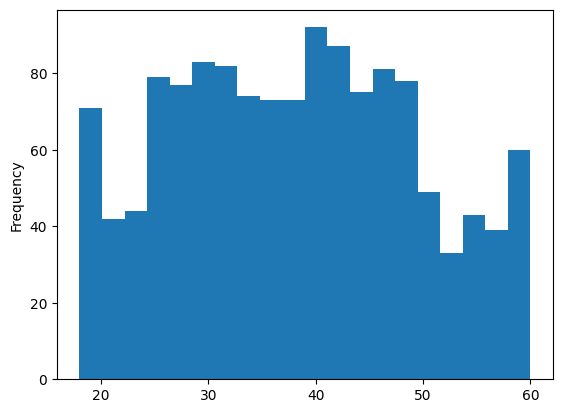

In [15]:
df['age'].plot(x ='age', y ='diabetic',kind = 'hist', bins = 20)

In [24]:
df[df['age'].isna()]

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
5,6,NaN,male,34.4,96,Yes,0,No,northwest,1137.47
6,7,NaN,male,37.3,86,Yes,0,No,northwest,1141.45


In [28]:
df[df['claim'] < 1160]

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
5,6,NaN,male,34.4,96,Yes,0,No,northwest,1137.47
6,7,NaN,male,37.3,86,Yes,0,No,northwest,1141.45
7,8,19.0,male,41.1,100,No,0,No,northwest,1146.80
8,9,20.0,male,43.0,86,No,0,No,northwest,1149.40
25,26,23.0,male,43.0,86,No,0,No,northwest,1149.40


In [34]:
df[['age', 'diabetic', 'bloodpressure']]

,age,diabetic,bloodpressure
0,39.0,Yes,91
1,24.0,No,87
2,NaN,Yes,82
3,NaN,No,80
4,NaN,No,100
...,...,...,...
1335,44.0,Yes,88
1336,59.0,No,120
1337,30.0,Yes,91
1338,37.0,No,106


In [37]:
fig = px.scatter(df, x='age', y='bloodpressure', color='diabetic',
                 title='Age vs Blood Pressure Grouped by Diabetic Status',
                 labels={'age': 'Age', 'bloodpressure': 'Blood Pressure', 'diabetic': 'Diabetic'})
fig.show()

In [51]:
filtered_df = df[(df['age'] <= 25) & (df['diabetic'] == 'Yes') & (df['smoker'] == 'Yes')]
display(filtered_df[['age', 'diabetic', 'smoker', 'claim']])

,age,diabetic,smoker,claim
1009,22.0,Yes,Yes,17043.34
1010,25.0,Yes,Yes,17081.08
1016,19.0,Yes,Yes,17361.77
1019,23.0,Yes,Yes,17560.38
1032,22.0,Yes,Yes,18259.22
1055,25.0,Yes,Yes,19444.27
1065,23.0,Yes,Yes,19933.46
1068,19.0,Yes,Yes,20149.32
1091,22.0,Yes,Yes,21472.48
1138,20.0,Yes,Yes,24915.22


In [60]:
px.histogram(df,x='age', y= 'claim')

In [61]:
df.head(
)

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [62]:
px.histogram(df,x='bmi', y= 'claim')

In [67]:
fig = px.histogram(df, x='claim', nbins=50, title='Distribution of Claim Amounts',
                 labels={'claim': 'Claim Amount', 'count': 'Frequency'})
fig.show()

In [95]:
fig = px.scatter(df, x='age', y='children', color='diabetic', facet_col='smoker',
                 title='Age vs Children Grouped by Smoker and Diabetic Status',
                 labels={'age': 'Age', 'children': 'Number of Children', 'diabetic': 'Diabetic', 'smoker': 'Smoker'})
fig.show()

In [96]:
# Aggregate data to get counts for each unique combination of attributes
df_agg_plot = df.groupby(['age', 'children', 'diabetic', 'smoker']).size().reset_index(name='count')

# Create the scatter plot with marker size representing the 'count'
fig = px.scatter(df_agg_plot, x='age', y='children', color='diabetic',
                 facet_col='smoker', size='count',
                 title='Age vs Children Grouped by Smoker and Diabetic Status (with Counts)',
                 labels={'age': 'Age', 'children': 'Number of Children', 'diabetic': 'Diabetic', 'smoker': 'Smoker', 'count': 'Number of People'},
                 hover_data={'count':True}) # Show count on hover
fig.show()

In [98]:
diabetic_smoker_counts = df.groupby(['smoker', 'diabetic']).size().reset_index(name='count')

fig = px.bar(diabetic_smoker_counts, x='smoker', y='count', color='diabetic',
             title='Diabetic Status by Smoker Group',
             labels={'smoker': 'Smoker Status', 'count': 'Number of Individuals', 'diabetic': 'Diabetic'})
fig.show()

In [102]:
fig = px.histogram(df, x='age', color='diabetic', barmode='group',
                 title='Age Distribution by Diabetic Status',
                 labels={'age': 'Age', 'count': 'Number of Individuals', 'diabetic': 'Diabetic'})
fig.show()

In [103]:
fig = px.histogram(df, x='age', color='diabetic', facet_col='smoker', barmode='group',
                 title='Age Distribution by Diabetic and Smoker Status',
                 labels={'age': 'Age', 'count': 'Number of Individuals', 'diabetic': 'Diabetic', 'smoker': 'Smoker'})
fig.show()

In [104]:
gender_diabetic_counts = df.groupby(['gender', 'diabetic']).size().reset_index(name='count')

fig = px.bar(gender_diabetic_counts, x='gender', y='count', color='diabetic',
             title='Diabetic Status by Gender',
             labels={'gender': 'Gender', 'count': 'Number of Individuals', 'diabetic': 'Diabetic'})
fig.show()

#Univariate Analysis

In [115]:
fig = px.box(df, x='gender', y='bloodpressure', color='diabetic', facet_col='region',
                 title='Blood Pressure Distribution by Gender, Diabetic Status, and Region',
                 labels={'gender': 'Gender', 'bloodpressure': 'Blood Pressure', 'diabetic': 'Diabetic', 'region': 'Region'})
fig.show()

### KDE Plots for Numerical Features

These plots show the probability density function of each numerical feature, giving a smoothed histogram to understand the distribution shape, peaks, and spreads.

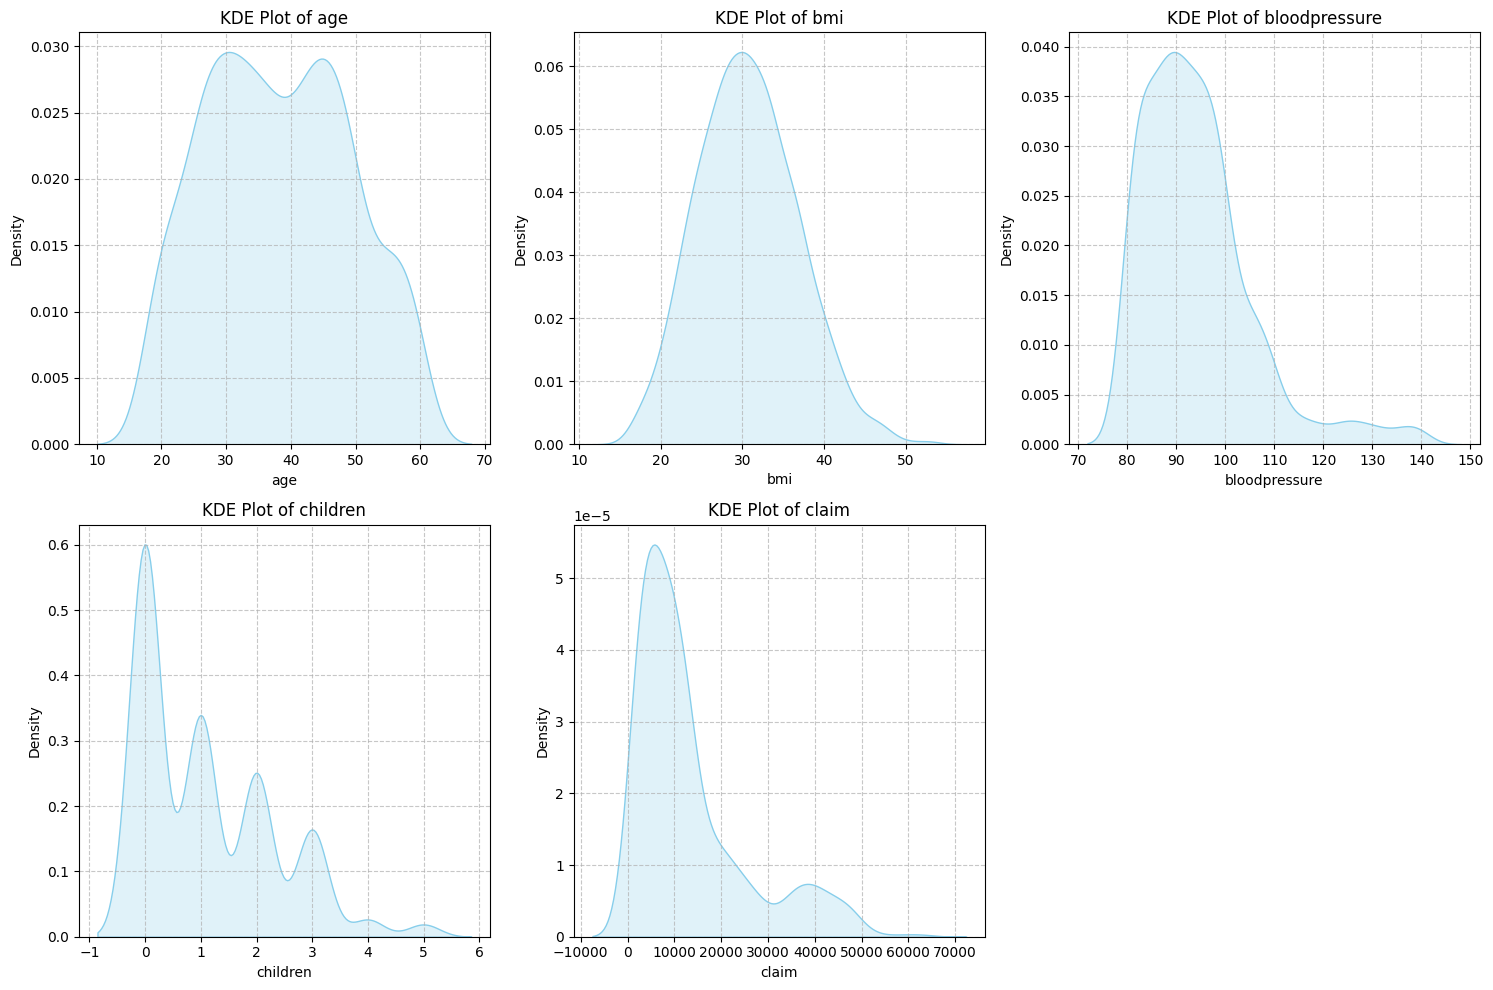

In [117]:
numerical_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.kdeplot(df[col], fill=True, color='skyblue')
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Correlation Heatmap

A heatmap of the correlation matrix helps visualize the linear relationships between numerical variables. Values closer to 1 or -1 indicate a stronger positive or negative correlation, respectively, while values near 0 suggest a weak or no linear relationship.

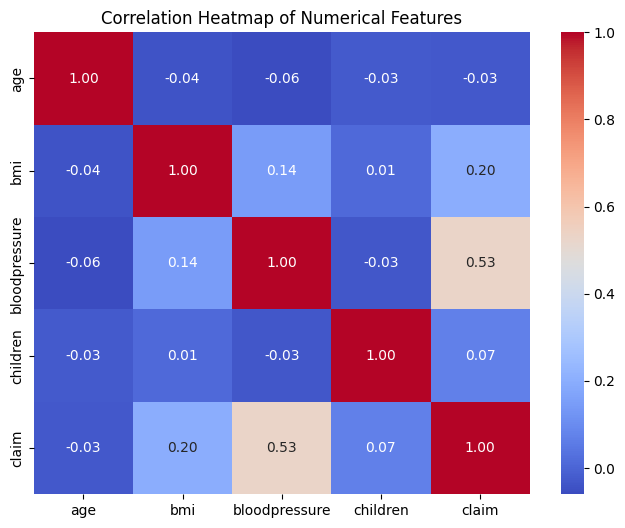

In [119]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Correlation Heatmap with Categorical Features (Label Encoded)

To include categorical features in the correlation heatmap, they are first converted into numerical representations using label encoding. While this allows their inclusion in the correlation matrix, the interpretation of correlations with these encoded variables should be done carefully. The numerical order assigned (e.g., 0, 1, 2 for categories) is arbitrary and might not reflect a meaningful linear relationship.

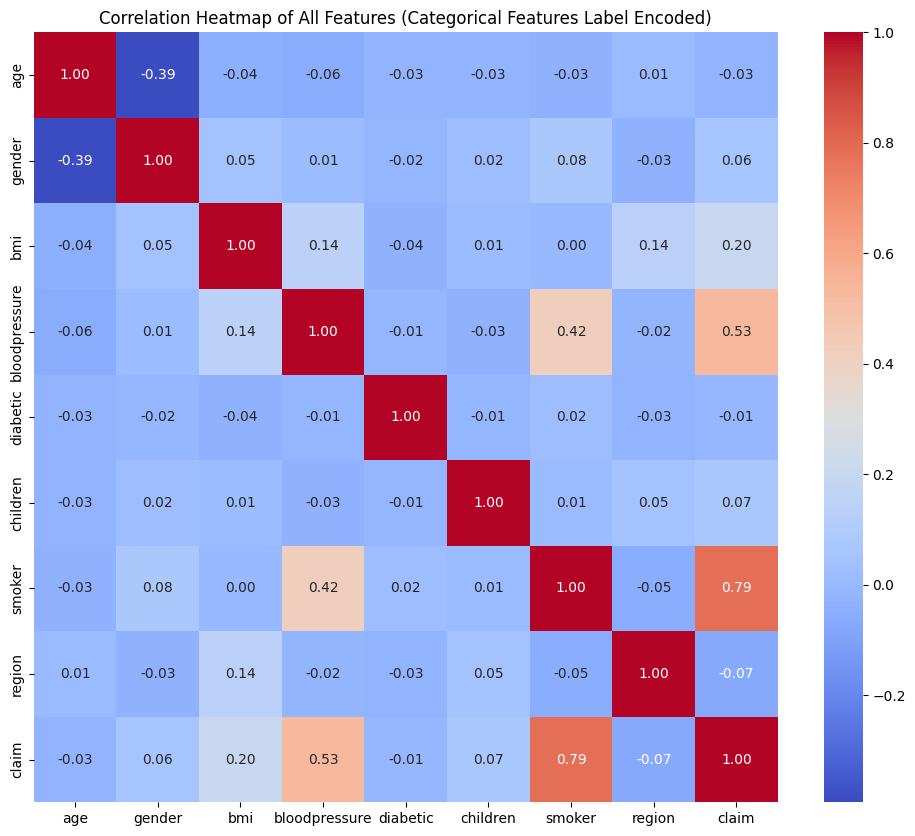

In [120]:
# Create a copy to avoid modifying the original DataFrame for this operation
df_encoded = df.copy()

# Drop 'PatientID' as it's an identifier and not relevant for correlation analysis
df_encoded = df_encoded.drop(columns=['PatientID'])

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include='object').columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Calculate the correlation matrix for the now fully numerical DataFrame
correlation_matrix_all = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features (Categorical Features Label Encoded)')
plt.show()

In [71]:
df.sample(20)

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1153,1154,43.0,male,36.8,126,No,2,No,northwest,26467.10
713,714,45.0,female,18.3,105,No,0,No,northwest,9991.04
897,898,40.0,male,29.7,87,Yes,2,No,southeast,12925.89
397,398,27.0,male,37.4,83,No,3,No,southeast,5428.73
879,880,36.0,male,43.4,96,No,0,No,southwest,12574.05
16,17,35.0,male,34.1,90,No,0,No,southwest,1261.44
196,197,30.0,male,30.9,89,Yes,0,No,northwest,3062.51
534,535,60.0,female,35.6,80,No,1,No,southeast,7345.73
41,42,18.0,male,27.8,93,No,0,No,northwest,1635.73
776,777,49.0,female,41.2,92,Yes,4,No,northwest,11033.66


In [121]:
gender_smoker_age_counts = df.groupby(['age', 'smoker', 'gender']).size().reset_index(name='count')

fig = px.scatter(gender_smoker_age_counts, x='age', y='smoker', color='gender',
                 size='count', hover_name='gender', title='Age and Smoker Status Grouped by Gender (with Counts)',
                 labels={'age': 'Age', 'smoker': 'Smoker Status', 'gender': 'Gender', 'count': 'Number of Individuals'})
fig.show()

In [122]:
fig = px.box(df, x='smoker', y='claim', color='gender',
                 title='Claim Amounts by Smoker Status and Gender',
                 labels={'smoker': 'Smoker Status', 'claim': 'Claim Amount', 'gender': 'Gender'})
fig.show()

In [124]:
fig = px.box(df, x='smoker', y='claim', color='gender', facet_col='diabetic',
                 title='Claim Amounts by Smoker Status, Gender, and Diabetic Status',
                 labels={'smoker': 'Smoker Status', 'claim': 'Claim Amount', 'gender': 'Gender', 'diabetic': 'Diabetic Status'})
fig.show()

In [126]:
fig = px.scatter(df, x='bmi', y='claim', color='gender', facet_col='diabetic',
                 hover_data=['bloodpressure'],
                 title='BMI vs Claim Amount by Gender and Diabetic Status',
                 labels={'bmi': 'BMI', 'claim': 'Claim Amount', 'gender': 'Gender', 'diabetic': 'Diabetic Status'})
fig.show()

In [128]:
fig = px.scatter(df, x='bmi', y='claim',
                 title='BMI vs Claim Amount',
                 labels={'bmi': 'BMI', 'claim': 'Claim Amount'})
fig.show()

In [129]:
fig = px.scatter(df, x='bmi', y='claim', color='smoker',
                 title='BMI vs Claim Amount by Smoker Status',
                 labels={'bmi': 'BMI', 'claim': 'Claim Amount', 'smoker': 'Smoker'})
fig.show()

In [131]:
fig = px.scatter(df, x='age', y='bloodpressure', color='claim',
                 title='Age vs Blood Pressure colored by Claim Amount',
                 labels={'age': 'Age', 'bloodpressure': 'Blood Pressure', 'claim': 'Claim Amount'},
                 color_continuous_scale=px.colors.sequential.Viridis) # Using a sequential color scale for claim
fig.show()

In [133]:
filtered_bp_df = df[df['bloodpressure'] > 110]

fig = px.scatter(filtered_bp_df, x='age', y='bloodpressure', color='claim',
                 title='Age vs Blood Pressure colored by Claim Amount (BP > 110)',
                 labels={'age': 'Age', 'bloodpressure': 'Blood Pressure', 'claim': 'Claim Amount'},
                 color_continuous_scale=px.colors.sequential.Viridis)
fig.show()

In [135]:
fig = px.scatter(df, x='bloodpressure', y='claim',
                 title='Blood Pressure vs Claim Amount',
                 labels={'bloodpressure': 'Blood Pressure', 'claim': 'Claim Amount'})
fig.show()

In [138]:
fig = px.scatter(df, x='age', y='claim',
                 title='Age vs Claim Amount',
                 labels={'age': 'Age', 'claim': 'Claim Amount'})
fig.show()

In [140]:
filtered_data = df[(df['claim'] < 20000) & (df['bloodpressure'] < 110)]
percentage = (len(filtered_data) / len(df)) * 100
print(f"Percentage of data with claim under $20,000 and blood pressure under 110: {percentage:.2f}%")

Percentage of data with claim under $20,000 and blood pressure under 110: 78.88%


In [136]:
fig = px.scatter(df, x='bloodpressure', y='claim', color='age',
                 title='Blood Pressure vs Claim Amount colored by Age',
                 labels={'bloodpressure': 'Blood Pressure', 'claim': 'Claim Amount', 'age': 'Age'},
                 color_continuous_scale=px.colors.sequential.Plasma) # Using a sequential color scale for age
fig.show()

In [143]:
fig = px.bar(df, x='age', y='children',
                 title='Age vs Number of Children',
                 labels={'age': 'Age', 'children': 'Number of Children'})
fig.show()

In [145]:
region_smoker_counts = df.groupby(['region', 'smoker']).size().reset_index(name='count')

fig = px.bar(region_smoker_counts, x='region', y='count', color='smoker',
             title='Smoker Status Distribution by Region',
             labels={'region': 'Region', 'count': 'Number of Individuals', 'smoker': 'Smoker Status'})
fig.show()

In [146]:
region_smoker_diabetic_counts = df.groupby(['region', 'smoker', 'diabetic']).size().reset_index(name='count')

fig = px.bar(region_smoker_diabetic_counts, x='region', y='count', color='diabetic',
             facet_col='smoker', barmode='group',
             title='Diabetic Status by Smoker Status and Region',
             labels={'region': 'Region', 'count': 'Number of Individuals', 'smoker': 'Smoker Status', 'diabetic': 'Diabetic Status'})
fig.show()

### Analysis by Age Group

To analyze the data by specific age groups (18-21, 21-24, etc.), I will create a new 'age_group' column and then group the data to observe trends in 'diabetic' status, 'bloodpressure', 'smoker', 'claim', and 'gender' within these groups.

In [148]:
# Define age bins and labels
bins = [18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60]
labels = ['18-21', '21-24', '24-27', '27-30', '30-33', '33-36', '36-39', '39-42', '42-45', '45-48', '48-51', '51-54', '54-57', '57-60']

# Create 'age_group' column, handling NaN values first
df_grouped = df.copy()
df_grouped['age_group'] = pd.cut(df_grouped['age'], bins=bins, labels=labels, right=False)

# Group by the specified columns and calculate the mean claim
# Also count the number of individuals in each group
summary_by_age_group = df_grouped.groupby(['age_group', 'gender', 'diabetic', 'smoker'], observed=False).agg(
    mean_bloodpressure=('bloodpressure', 'mean'),
    mean_claim=('claim', 'mean'),
    count=('PatientID', 'count')
).reset_index()

display(summary_by_age_group.head(10))

,age_group,gender,diabetic,smoker,mean_bloodpressure,mean_claim,count
0,18-21,female,No,No,NaN,NaN,0
1,18-21,female,No,Yes,NaN,NaN,0
2,18-21,female,Yes,No,NaN,NaN,0
3,18-21,female,Yes,Yes,NaN,NaN,0
4,18-21,male,No,No,93.333333,7357.090333,30
5,18-21,male,No,Yes,96.444444,32941.391111,9
6,18-21,male,Yes,No,91.560000,9928.227200,25
7,18-21,male,Yes,Yes,106.285714,32256.060000,7
8,21-24,female,No,No,NaN,NaN,0
9,21-24,female,No,Yes,NaN,NaN,0


In [150]:
# Filter out rows with NaN values in mean_claim for cleaner visualization
summary_for_plot = summary_by_age_group.dropna(subset=['mean_claim'])

fig = px.bar(summary_for_plot,
             x='age_group',
             y='mean_claim',
             color='smoker',
             facet_col='gender',
             barmode='group',
             title='Mean Claim Amount by Age Group, Gender, and Smoker Status',
             labels={'age_group': 'Age Group', 'mean_claim': 'Mean Claim Amount', 'smoker': 'Smoker Status', 'gender': 'Gender'},
             category_orders={'age_group': labels, 'smoker': ['No', 'Yes']})
fig.update_layout(xaxis={'categoryorder':'array', 'categoryarray':labels})
fig.show()

In [69]:
df.columns


Index(['PatientID', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic',
       'children', 'smoker', 'region', 'claim'],
      dtype='object')

In [76]:
df.groupby(['gender', 'smoker']).count()

PatientID  age  bmi  bloodpressure  diabetic  children  region  \
gender smoker                                                                   
female No            547  547  547            547       547       547     547   
       Yes           115  115  115            115       115       115     115   
male   No            519  514  519            519       519       519     516   
       Yes           159  159  159            159       159       159     159   

               claim  
gender smoker         
female No        547  
       Yes       115  
male   No        519  
       Yes       159

In [81]:
df.groupby([ 'smoker','age']).count()

PatientID  gender  bmi  bloodpressure  diabetic  children  \
smoker age                                                               
No     18.0         15      15   15             15        15        15   
       19.0         22      22   22             22        22        22   
       20.0         18      18   18             18        18        18   
       21.0         14      14   14             14        14        14   
       22.0         12      12   12             12        12        12   
...                ...     ...  ...            ...       ...       ...   
Yes    56.0          4       4    4              4         4         4   
       57.0          2       2    2              2         2         2   
       58.0          5       5    5              5         5         5   
       59.0          4       4    4              4         4         4   
       60.0          5       5    5              5         5         5   

             region  claim  
smoker age                  
No     18.0      15     15  
       19.0      22     22  
       20.0      18     18  
       21.0      14     14  
       22.0      12     12  
...             ...    ...  
Yes    56.0       4      4  
       57.0       2      2  
       58.0       5      5  
       59.0       4      4  
       60.0       5      5  

[85 rows x 8 columns]

In [83]:
df.groupby([ 'region', 'bloodpressure']).count()

PatientID  age  gender  bmi  diabetic  children  \
region    bloodpressure                                                    
northeast 80                     9    9       9    9         9         9   
          81                    12   12      12   12        12        12   
          82                    14   14      14   14        14        14   
          83                    14   14      14   14        14        14   
          84                     5    5       5    5         5         5   
...                            ...  ...     ...  ...       ...       ...   
southwest 132                    1    1       1    1         1         1   
          135                    1    1       1    1         1         1   
          136                    1    1       1    1         1         1   
          139                    1    1       1    1         1         1   
          140                    2    2       2    2         2         2   

                         smoker  claim  
region    bloodpressure                 
northeast 80                  9      9  
          81                 12     12  
          82                 14     14  
          83                 14     14  
          84                  5      5  
...                         ...    ...  
southwest 132                 1      1  
          135                 1      1  
          136                 1      1  
          139                 1      1  
          140                 2      2  

[186 rows x 8 columns]

In [84]:
df.groupby([ 'diabetic', 'bloodpressure']).count()

PatientID  age  gender  bmi  children  smoker  region  \
diabetic bloodpressure                                                          
No       80                    29   28      29   29        29      29      29   
         81                    29   29      29   29        29      29      29   
         82                    27   27      27   27        27      27      27   
         83                    26   26      26   26        26      26      26   
         84                    23   23      23   23        23      23      23   
...                           ...  ...     ...  ...       ...     ...     ...   
Yes      136                    1    1       1    1         1       1       1   
         137                    2    2       2    2         2       2       2   
         138                    1    1       1    1         1       1       1   
         139                    1    1       1    1         1       1       1   
         140                    4    4       4    4         4       4       4   

                        claim  
diabetic bloodpressure         
No       80                29  
         81                29  
         82                27  
         83                26  
         84                23  
...                       ...  
Yes      136                1  
         137                2  
         138                1  
         139                1  
         140                4  

[108 rows x 8 columns]

In [89]:
df.groupby([ 'diabetic', 'bmi']).count()

PatientID  age  gender  bloodpressure  children  smoker  \
diabetic bmi                                                             
No       16.0          1    1       1              1         1       1   
         16.8          1    1       1              1         1       1   
         17.3          1    1       1              1         1       1   
         17.4          2    2       2              2         2       2   
         17.8          2    2       2              2         2       2   
...                  ...  ...     ...            ...       ...     ...   
Yes      47.5          1    1       1              1         1       1   
         47.6          1    1       1              1         1       1   
         48.1          1    1       1              1         1       1   
         49.1          1    1       1              1         1       1   
         50.4          1    1       1              1         1       1   

               region  claim  
diabetic bmi                  
No       16.0       1      1  
         16.8       1      1  
         17.3       1      1  
         17.4       2      2  
         17.8       2      2  
...               ...    ...  
Yes      47.5       1      1  
         47.6       1      1  
         48.1       1      1  
         49.1       1      1  
         50.4       1      1  

[460 rows x 8 columns]

In [92]:
df.children.unique()

array([0, 1, 2, 3, 4, 5])